Dataset Prepared Successfully
Date
2024-01-01    34.0
2024-01-02    34.2
2024-01-03    32.8
2024-01-04    29.9
2024-01-05    34.4
Freq: D, Name: Temperature_Avg (°C), dtype: float64


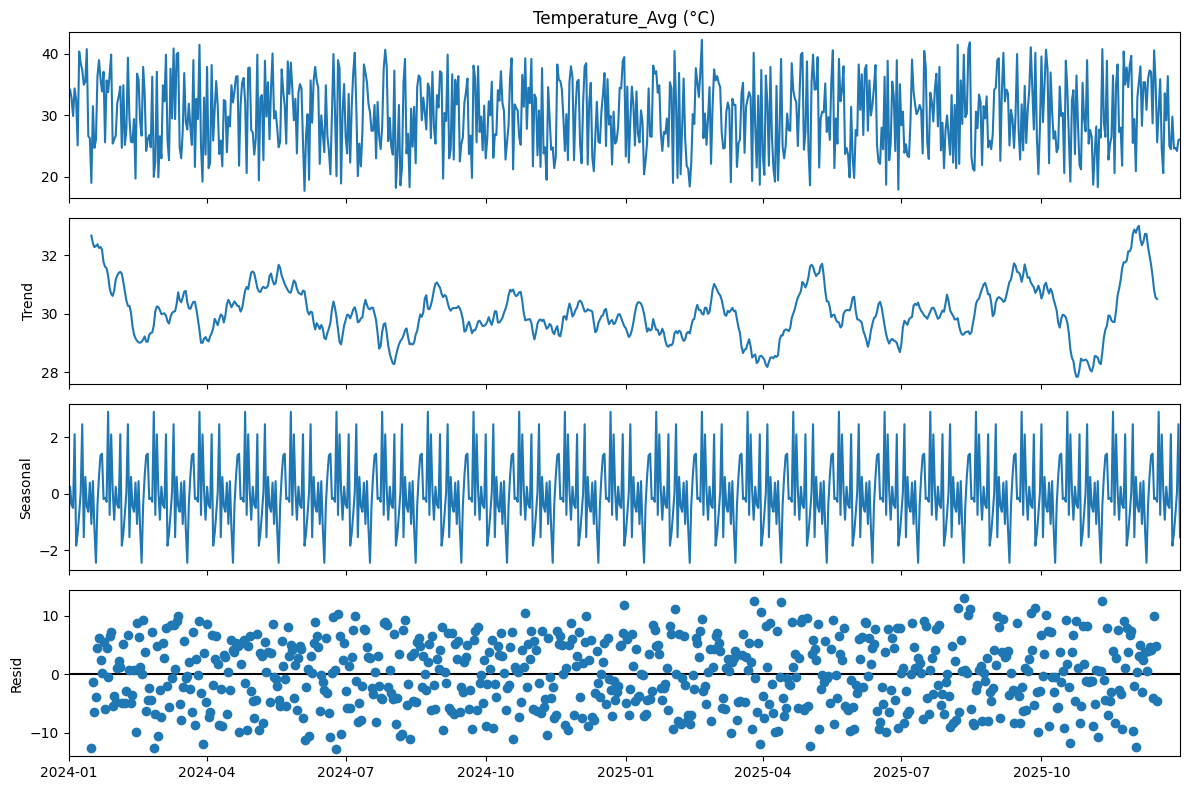


Training ARIMA Model...
                                SARIMAX Results                                 
Dep. Variable:     Temperature_Avg (°C)   No. Observations:                  731
Model:                   ARIMA(1, 1, 1)   Log Likelihood               -2346.809
Date:                  Fri, 15 May 2026   AIC                           4699.617
Time:                          11:36:58   BIC                           4713.396
Sample:                      01-01-2024   HQIC                          4704.933
                           - 12-31-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0110      0.037      0.295      0.768      -0.062       0.084
ma.L1         -0.9996      0.034    -29.086      0.000      -1.067      -0.932
sigma2     

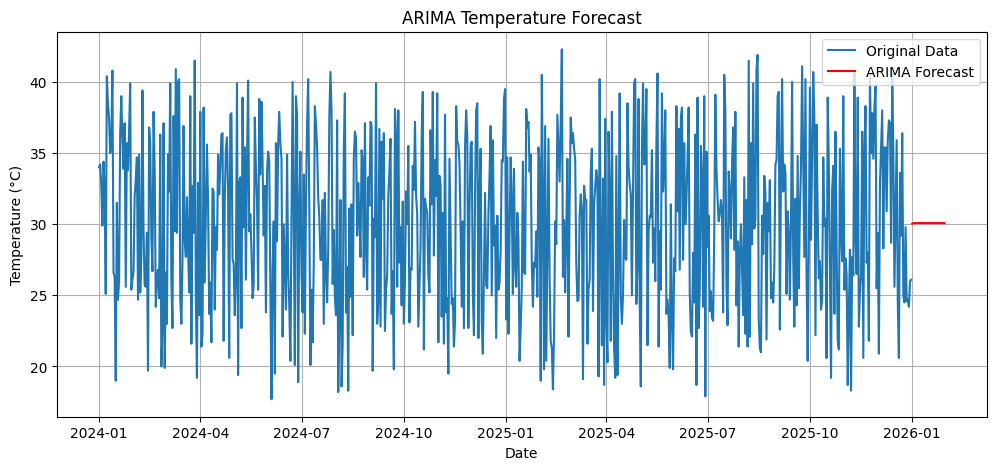


Training SARIMA Model...
                                     SARIMAX Results                                      
Dep. Variable:               Temperature_Avg (°C)   No. Observations:                  731
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 30)   Log Likelihood               -2186.999
Date:                            Fri, 15 May 2026   AIC                           4383.999
Time:                                    11:37:16   BIC                           4406.520
Sample:                                01-01-2024   HQIC                          4392.723
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0044      0.040      0.111      0.911      -0.073       0.082
ma.L1    

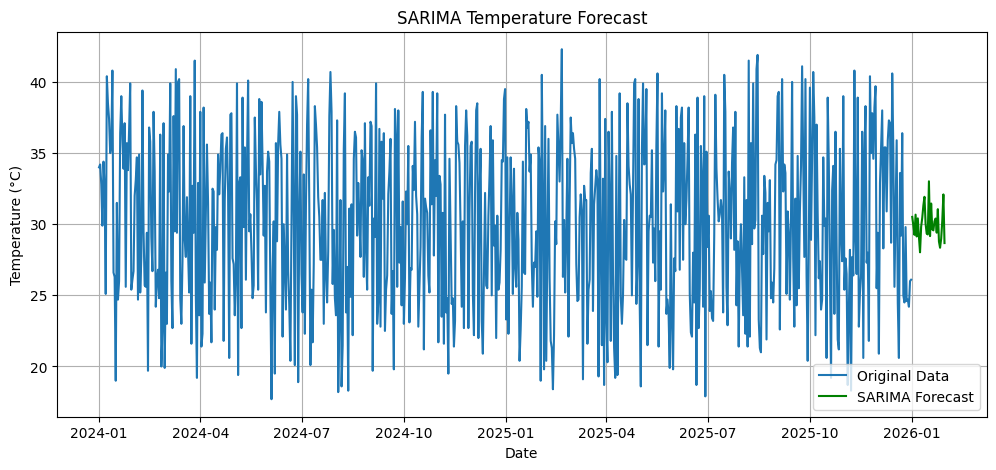


Forecast for Next 30 Days:
         Date  ARIMA Forecast  SARIMA Forecast
0  2026-01-01       30.035409        30.515605
1  2026-01-02       30.078664        29.895100
2  2026-01-03       30.079140        29.254065
3  2026-01-04       30.079145        30.672710
4  2026-01-05       30.079145        29.138859
5  2026-01-06       30.079145        30.410054
6  2026-01-07       30.079145        29.128358
7  2026-01-08       30.079145        28.026527
8  2026-01-09       30.079145        29.825380
9  2026-01-10       30.079145        30.453172
10 2026-01-11       30.079145        31.316345
11 2026-01-12       30.079145        31.926909
12 2026-01-13       30.079145        30.032062
13 2026-01-14       30.079145        29.334047
14 2026-01-15       30.079145        29.281913
15 2026-01-16       30.079145        33.016911
16 2026-01-17       30.079145        29.165861
17 2026-01-18       30.079145        31.454734
18 2026-01-19       30.079145        29.634331
19 2026-01-20       30.079145   

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# =========================================
# STEP 1: LOAD AND PREPARE DATA
# =========================================

# Load dataset
df = pd.read_csv(r"C:\Users\SCA_11\Downloads\Indian_Climate_Dataset_2024_2025.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Select Bengaluru data
df = df[df['City'] == 'Bengaluru']

# Keep only needed columns
df = df[['Date', 'Temperature_Avg (°C)']]

# Remove missing values
df = df.dropna()

# Set Date as index
df = df.set_index('Date')

# Sort dates properly
df = df.sort_index()

# Set daily frequency
df = df.asfreq('D')

# Fill missing values created by asfreq()
df['Temperature_Avg (°C)'] = df['Temperature_Avg (°C)'].interpolate()

# Final target series
data = df['Temperature_Avg (°C)']

print("Dataset Prepared Successfully")
print(data.head())

# =========================================
# STEP 2: TIME SERIES DECOMPOSITION
# =========================================

# Use smaller seasonal period for stability
decomposition = seasonal_decompose(
    data,
    model='additive',
    period=30
)

# Plot decomposition
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

# =========================================
# STEP 3: ARIMA MODEL
# =========================================

print("\nTraining ARIMA Model...")

arima_model = ARIMA(
    data,
    order=(1, 1, 1)
)

arima_fit = arima_model.fit()

print(arima_fit.summary())

# Forecast next 30 days
arima_forecast = arima_fit.forecast(steps=30)

# Create forecast dates
forecast_dates = pd.date_range(
    start=data.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq='D'
)

# Plot ARIMA forecast
plt.figure(figsize=(12, 5))

plt.plot(data, label='Original Data')
plt.plot(forecast_dates,
         arima_forecast,
         color='red',
         label='ARIMA Forecast')

plt.title("ARIMA Temperature Forecast")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

# =========================================
# STEP 4: SARIMA MODEL
# =========================================

print("\nTraining SARIMA Model...")

sarima_model = SARIMAX(
    data,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 30),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

# Forecast next 30 days
sarima_forecast = sarima_fit.forecast(steps=30)

# Plot SARIMA forecast
plt.figure(figsize=(12, 5))

plt.plot(data, label='Original Data')

plt.plot(forecast_dates,
         sarima_forecast,
         color='green',
         label='SARIMA Forecast')

plt.title("SARIMA Temperature Forecast")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

# =========================================
# STEP 5: PRINT FORECAST VALUES
# =========================================

forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'ARIMA Forecast': arima_forecast.values,
    'SARIMA Forecast': sarima_forecast.values
})

print("\nForecast for Next 30 Days:")
print(forecast_df)